In [ ]:
import os
from typing import Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)
print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [5]:
vectorstore = Chroma(
    collection_name="rag_decomposition",
    embedding_function=embeddings,
)
vectorstore.add_documents(documents=chunks)
print("Vector store ready")

Vector store ready


In [ ]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
agent_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [7]:
class AgenticRAGState(MessagesState):
    
    query: str
    retrieved_docs: list[Document]
    relevant_docs: list[Document]
    context: str
    generation: str
    needs_retrieval: bool
    retrieval_count: int
    max_retrieval_steps: int
    is_relevant: bool
    rewritten_query: str  
    rewrite_count: int    
    needs_decomposition: bool

In [8]:
class RouteDecision(BaseModel):
    needs_retrieval: bool

In [9]:
class RelevanceEvaluation(BaseModel):
    is_relevant: bool

In [10]:
class DecompositionDecision(BaseModel):
    needs_decomposition: bool
    sub_queries: list[str]  # empty list when needs_decomposition=False

In [11]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    docs = vectorstore.similarity_search(query, k=k)
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

In [12]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

In [13]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [14]:
def check_decomposition(state: AgenticRAGState) -> dict:
    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query analysis assistant. Determine if the user's question asks for "
            "multiple distinct pieces of information that each require separate retrieval. "
            "If yes, needs_decomposition should be True. "
            "If the question is simple or self-contained, needs_decomposition should be False."
        ),
        ("human", "{query}"),
    ])
    
    chain = prompt_template | llm.with_structured_output(DecompositionDecision)
    result = chain.invoke({"query": state["query"]})
    
    return {"needs_decomposition": result.needs_decomposition}

In [15]:
def decompose_query(state: AgenticRAGState) -> dict:
    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query decomposition assistant. Break the user's question into focused, "
            "self-contained sub-queries — one per retrieval step. Each sub-query should target "
            "a single distinct piece of information."
        ),
        ("human", "{query}"),
    ])
    
    chain = prompt_template | llm.with_structured_output(DecompositionDecision)
    result = chain.invoke({"query": state["query"]})
    
    formatted = "\n".join(f"Step {i+1}: {q}" for i, q in enumerate(result.sub_queries))
    
    return {"query": formatted}

In [16]:
def route_question(state: AgenticRAGState) -> dict:
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])
    
    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})
    
    return {"needs_retrieval": decision.needs_retrieval}

In [17]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools.\n\n"
    "When the query contains numbered steps (e.g. Step 1: ..., Step 2: ...), each step is a separate "
    "retrieval sub-task. Make sure every step receives at least one retrieval call — do not skip or "
    "overlook any step. For each step, choose whichever tool or combination of tools best fits the "
    "information need; the retrieval path for each step is yours to decide."
)

def agent(state: AgenticRAGState) -> dict:
    # use rewritten_query if available to start a fresh retrieval cycle
    rewritten = state.get("rewritten_query")

    if rewritten:
        messages = [
            SystemMessage(content=AGENT_SYSTEM_PROMPT),
            HumanMessage(content=rewritten),
        ]

    else:
        messages = state["messages"]
        if not messages:
            messages = [
                SystemMessage(content=AGENT_SYSTEM_PROMPT),
                HumanMessage(content=state["query"]),
            ]

    response = agent_llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [18]:
def collect_tool_output(state: AgenticRAGState) -> dict:
    all_docs = []
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            break
        if isinstance(msg, ToolMessage):
            all_docs.extend(msg.artifact)
    all_docs.reverse()
    return {"retrieved_docs": all_docs}

In [19]:
def evaluate_docs(state: AgenticRAGState) -> dict:
    docs = state.get("retrieved_docs") or []
    if not docs:
        return {"is_relevant": False, "relevant_docs": [], "context": ""}

    active_query = state.get("rewritten_query") or state["query"]

    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a relevance evaluator. Given a user query and a single document passage, "
            "determine whether the passage contains useful information to answer the query. "
            "Return is_relevant=True only if the passage directly addresses the query with specific facts or analysis. "
            "Return is_relevant=False if it is off-topic, too vague, or does not help answer the query."
        ),
        ("human", "Query: {query}\n\nDocument passage:\n{doc}"),
    ])
    chain = prompt_template | llm.with_structured_output(RelevanceEvaluation)

    relevant_docs = []
    for doc in docs:
        result = chain.invoke({"query": active_query, "doc": doc.page_content})
        if result.is_relevant:
            relevant_docs.append(doc)

    is_relevant = len(relevant_docs) > 0
    context = "\n\n".join(d.page_content for d in relevant_docs)

    return {"is_relevant": is_relevant, "relevant_docs": relevant_docs, "context": context}

In [20]:
def rewrite_query(state: AgenticRAGState) -> dict:
    count = state.get("rewrite_count", 0)

    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query rewriting assistant. A retrieval system searched for information to answer the user's "
            "query but none of the retrieved documents were relevant. Your task is to rewrite the query to be more "
            "specific, use different terminology, or focus on a narrower aspect that is more likely to match "
            "content in the knowledge source. Return only the rewritten query string."
        ),
        ("human", "Original query: {query}\n\nRewritten query:"),
    ])
    chain = prompt_template | llm
    response = chain.invoke({"query": state["query"]})
    new_query = response.content.strip()

    return {"rewritten_query": new_query, "rewrite_count": count + 1}

In [21]:
def generate(state: AgenticRAGState) -> dict:
    # no-answer fallback when all rewrite attempts are exhausted with no relevant docs
    if state.get("rewrite_count", 0) >= 3 and not state.get("is_relevant"):
        return {
            "generation": (
                "I was unable to find relevant information to answer your query after multiple retrieval attempts. "
                "The knowledge source does not appear to contain content that addresses this question."
            )
        }

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})
    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [22]:
def check_retrieval_limit(state: AgenticRAGState) -> dict:
    count = state.get("retrieval_count", 0)
    return {"retrieval_count": count + 1}

In [23]:
def route_after_classification(state: AgenticRAGState) -> Literal["check_decomposition", "generate"]:
    return "check_decomposition" if state["needs_retrieval"] else "generate"

def route_after_decomposition_check(state: AgenticRAGState) -> Literal["decompose_query", "agent"]:
    return "decompose_query" if state["needs_decomposition"] else "agent"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

def route_after_limit_check(state: AgenticRAGState) -> Literal["agent", "collect_tool_output"]:
    return "collect_tool_output" if state["retrieval_count"] >= state["max_retrieval_steps"] else "agent"

def route_after_evaluation(state: AgenticRAGState) -> Literal["generate", "rewrite_query"]:
    return "generate" if state["is_relevant"] else "rewrite_query"

def route_after_rewrite(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "generate" if state.get("rewrite_count", 0) >= 3 else "agent"

In [24]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("check_decomposition", check_decomposition)
graph_builder.add_node("decompose_query", decompose_query)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("check_retrieval_limit", check_retrieval_limit)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("evaluate_docs", evaluate_docs)
graph_builder.add_node("rewrite_query", rewrite_query)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("check_decomposition", route_after_decomposition_check)
graph_builder.add_edge("decompose_query", "agent")
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "check_retrieval_limit")
graph_builder.add_conditional_edges("check_retrieval_limit", route_after_limit_check)
graph_builder.add_edge("collect_tool_output", "evaluate_docs")
graph_builder.add_conditional_edges("evaluate_docs", route_after_evaluation)
graph_builder.add_conditional_edges("rewrite_query", route_after_rewrite)
graph_builder.add_edge("generate", END)

In [25]:
graph = graph_builder.compile()

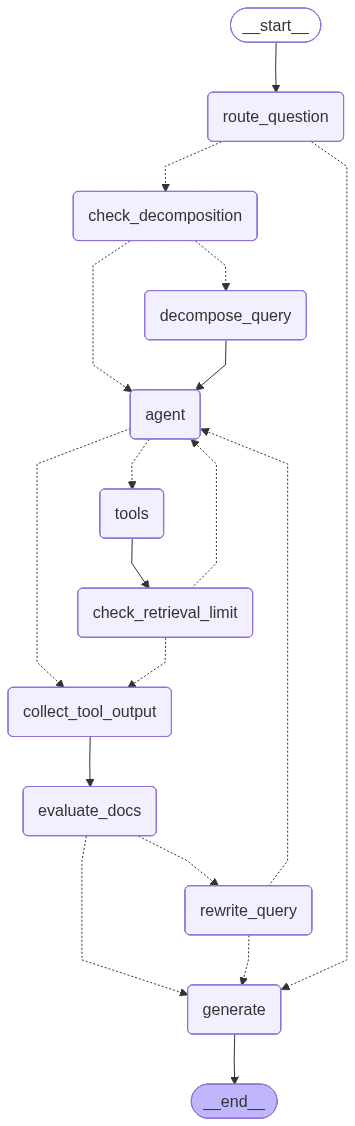

In [26]:
graph

In [27]:
# Case 1: simple query — expect no decomposition, query unchanged
query_1 = (
    "According to the report, by how many million barrels per day could a 300-million EV fleet "
    "displace oil demand by 2030?"
)

result_1 = graph.invoke({
    "query": query_1,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 1: Simple query — no decomposition ===")
print("Final query:", result_1.get("query"))
print("Is relevant:", result_1.get("is_relevant"))
print("Relevant docs count:", len(result_1.get("relevant_docs") or []))
print("\nGeneration:\n", result_1.get("generation"))

=== Case 1: Simple query — no decomposition ===
Final query: According to the report, by how many million barrels per day could a 300-million EV fleet displace oil demand by 2030?
Is relevant: True
Relevant docs count: 1

Generation:
 About 4.6 million barrels per day.


In [ ]:
# Case 2: complex multi-part query — expect decomposition into numbered steps

query_2 = (
    "Impact of EVs on the oil industry, "
    "and what is the current price of oil in US dollars for Brent Crude"
)

result_2 = graph.invoke({
    "query": query_2,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 10,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 2: Complex query — decomposition expected ===")
print("Final query (after decomposition):\n", result_2.get("query"))
print("\nIs relevant:", result_2.get("is_relevant"))
print("Relevant docs count:", len(result_2.get("relevant_docs") or []))
print("Retrieval count:", result_2.get("retrieval_count"))
print("\nGeneration:\n", result_2.get("generation"))

=== Case 2: Complex query — decomposition expected ===
Final query (after decomposition):
 Step 1: What has been the historical impact of electric vehicle (EV) adoption on global oil demand over the past 5–10 years (annual figures and percent change), citing authoritative sources (IEA, BP, etc.)?
Step 2: What do major energy outlooks and scenarios (IEA Net Zero, IEA Stated Policies, BP Energy Outlook, OPEC, etc.) project for future oil demand reductions specifically attributable to EV adoption through 2030 and 2040 (quantified in million barrels per day)?
Step 3: How has increasing EV adoption affected gasoline and diesel consumption trends (vehicle-km traveled, fuel-economy-adjusted consumption) in major markets (US, EU, China)?
Step 4: What measurable impacts are EVs having on oil industry finances and operations: revenues, upstream capital expenditures, and investment in new exploration and production (with recent examples or company statements)?
Step 5: How is EV growth affecting r